In [2]:
import warnings
warnings.filterwarnings("ignore")

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Save Model
import joblib

In [3]:
df = pd.read_csv("../Datasets/AB_NYC_2019.csv")

In [4]:
df.shape

(48895, 16)

In [5]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [6]:
df.tail()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2
48894,36487245,Trendy duplex in the very heart of Hell's Kitchen,68119814,Christophe,Manhattan,Hell's Kitchen,40.76404,-73.98933,Private room,90,7,0,NaN,NaN,1,23


In [7]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [9]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [10]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [11]:
df.drop(
    columns=["id", "name", "host_id", "host_name", "last_review"],
    inplace=True
)

In [12]:
df["reviews_per_month"].fillna(
    df["reviews_per_month"].median(),
    inplace=True
)

0        0.21
1        0.38
2        0.72
3        4.64
4        0.10
         ... 
48890    0.72
48891    0.72
48892    0.72
48893    0.72
48894    0.72
Name: reviews_per_month, Length: 48895, dtype: float64

In [19]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(df["reviews_per_month"].median())

In [20]:
df.isnull().sum()

neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

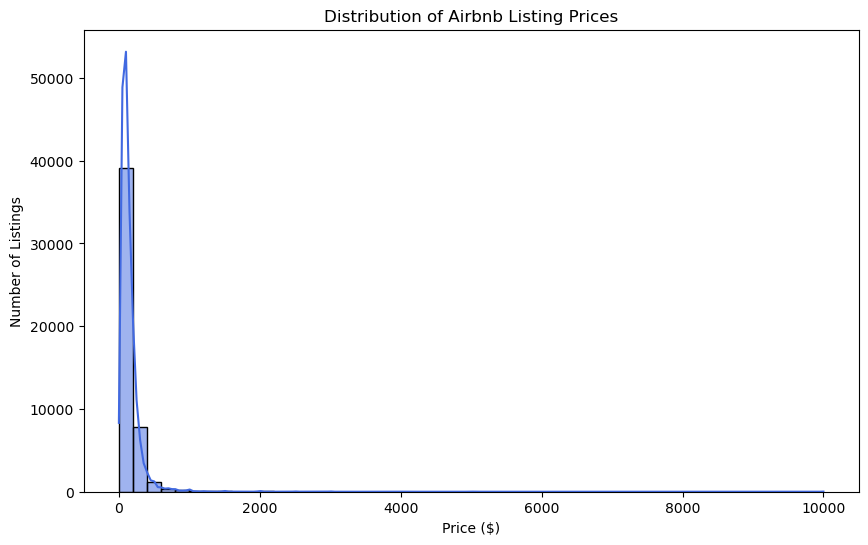

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(df["price"], bins=50, kde=True, color="royalblue")

plt.title("Distribution of Airbnb Listing Prices")
plt.xlabel("Price ($)")
plt.ylabel("Number of Listings")

plt.show()

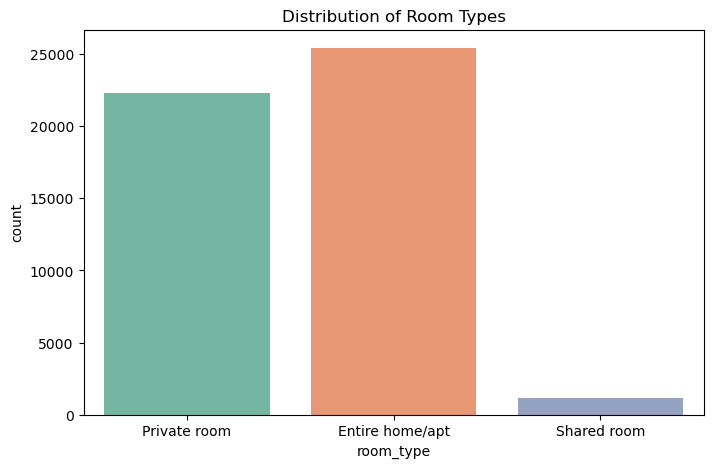

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="room_type",
    data=df,
    palette="Set2"
)

plt.title("Distribution of Room Types")

plt.show()

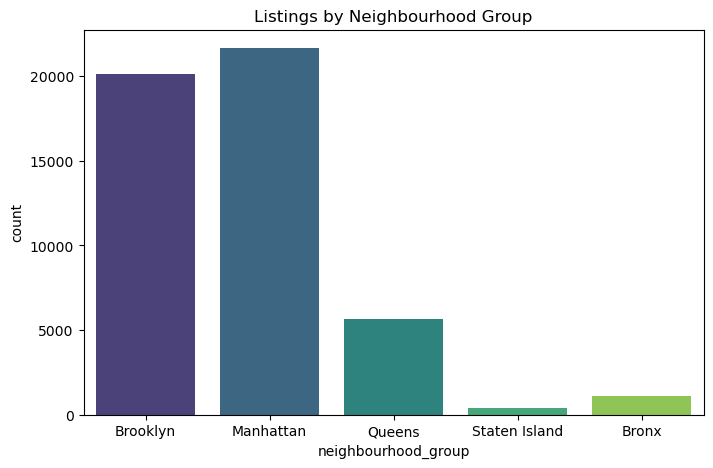

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="neighbourhood_group",
    data=df,
    palette="viridis"
)

plt.title("Listings by Neighbourhood Group")

plt.show()

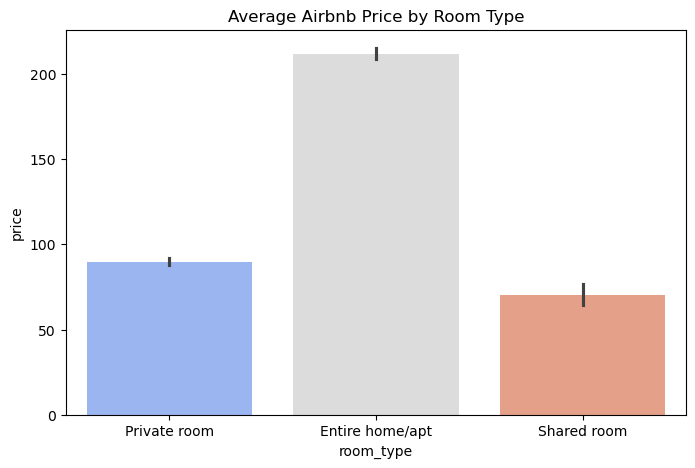

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="room_type",
    y="price",
    data=df,
    estimator="mean",
    palette="coolwarm"
)

plt.title("Average Airbnb Price by Room Type")

plt.show()

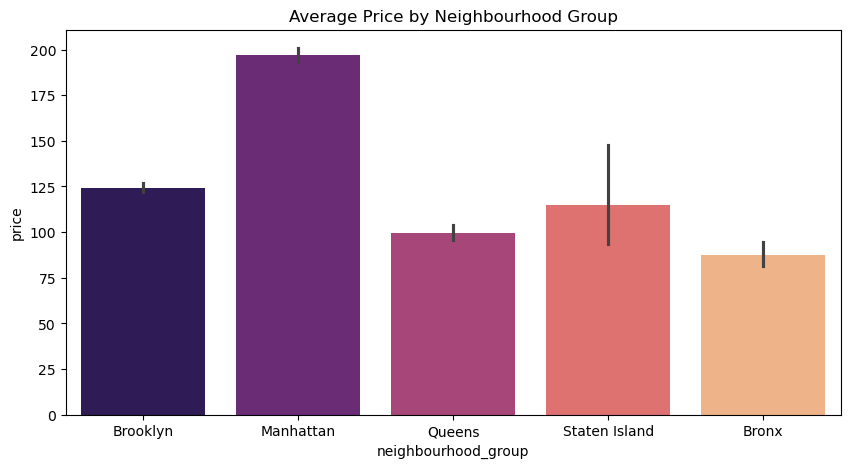

In [25]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="neighbourhood_group",
    y="price",
    data=df,
    estimator="mean",
    palette="magma"
)

plt.title("Average Price by Neighbourhood Group")

plt.show()

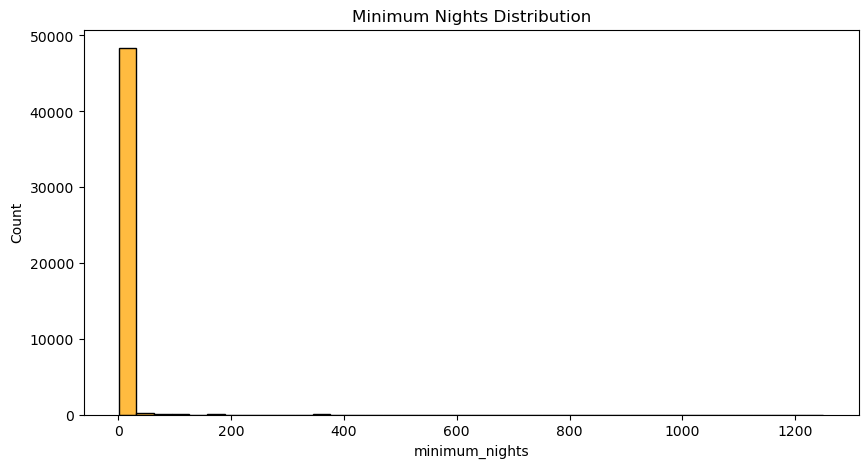

In [26]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["minimum_nights"],
    bins=40,
    color="orange"
)

plt.title("Minimum Nights Distribution")

plt.show()

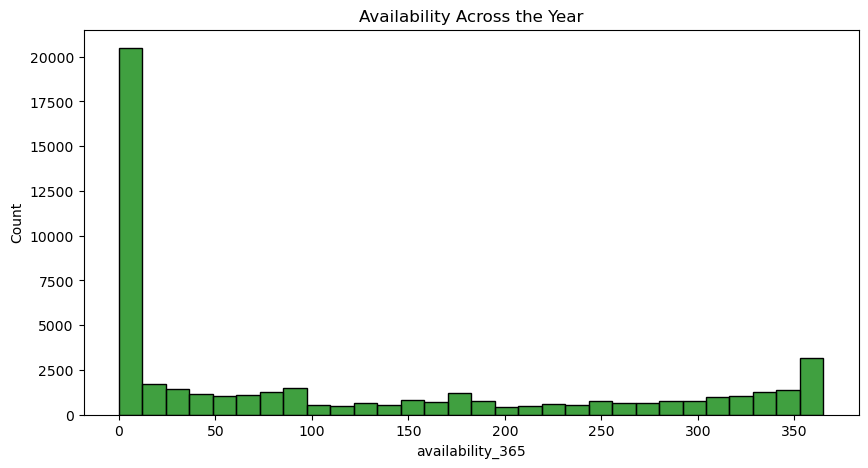

In [27]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["availability_365"],
    bins=30,
    color="green"
)

plt.title("Availability Across the Year")

plt.show()

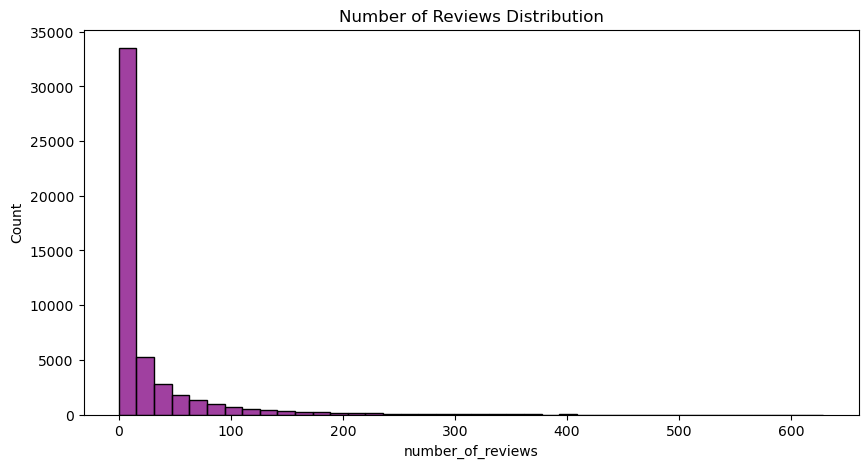

In [28]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["number_of_reviews"],
    bins=40,
    color="purple"
)

plt.title("Number of Reviews Distribution")

plt.show()

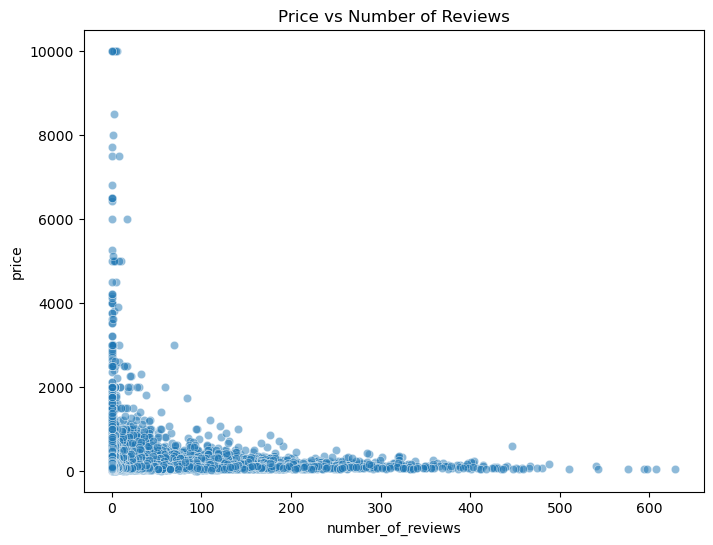

In [29]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="number_of_reviews",
    y="price",
    data=df,
    alpha=0.5
)

plt.title("Price vs Number of Reviews")

plt.show()

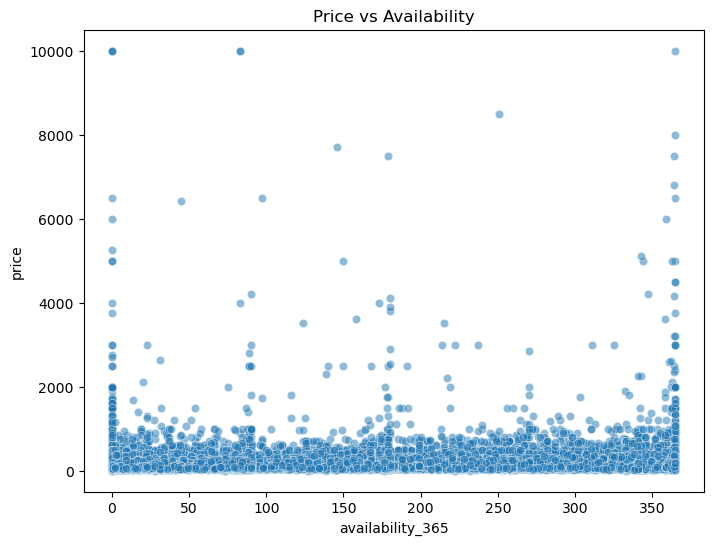

In [30]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="availability_365",
    y="price",
    data=df,
    alpha=0.5
)

plt.title("Price vs Availability")

plt.show()

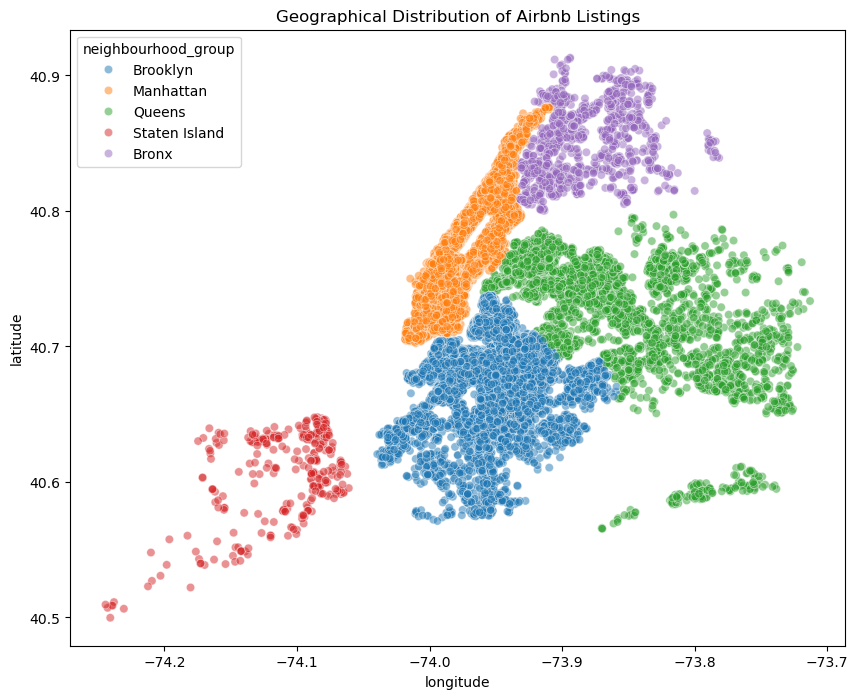

In [31]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    x="longitude",
    y="latitude",
    hue="neighbourhood_group",
    data=df,
    alpha=0.5
)

plt.title("Geographical Distribution of Airbnb Listings")

plt.show()

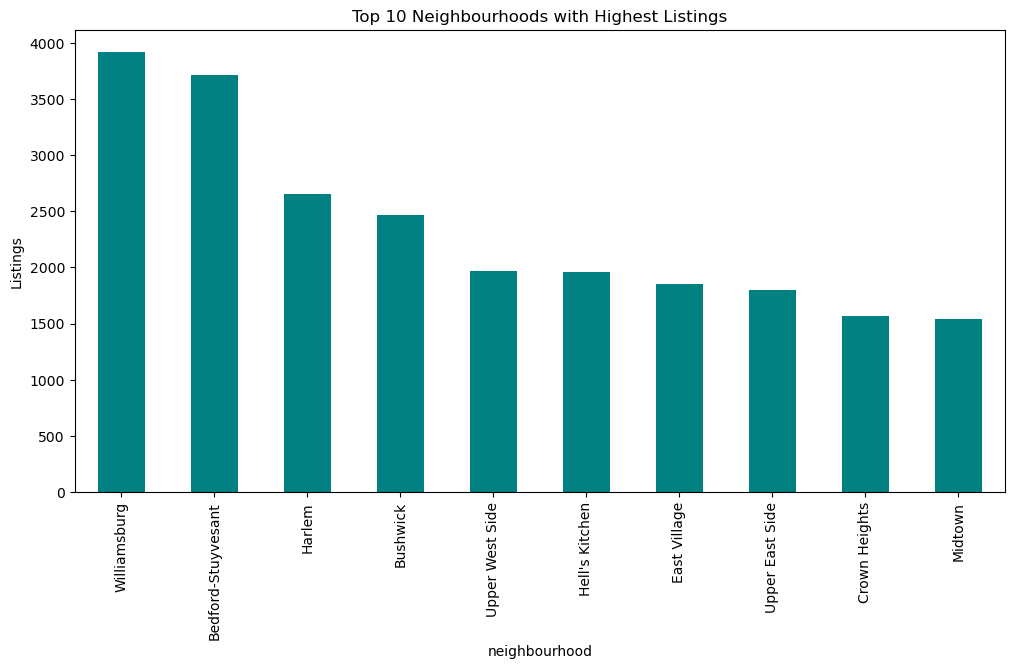

In [32]:
plt.figure(figsize=(12,6))

df["neighbourhood"].value_counts().head(10).plot(
    kind="bar",
    color="teal"
)

plt.title("Top 10 Neighbourhoods with Highest Listings")

plt.ylabel("Listings")

plt.show()

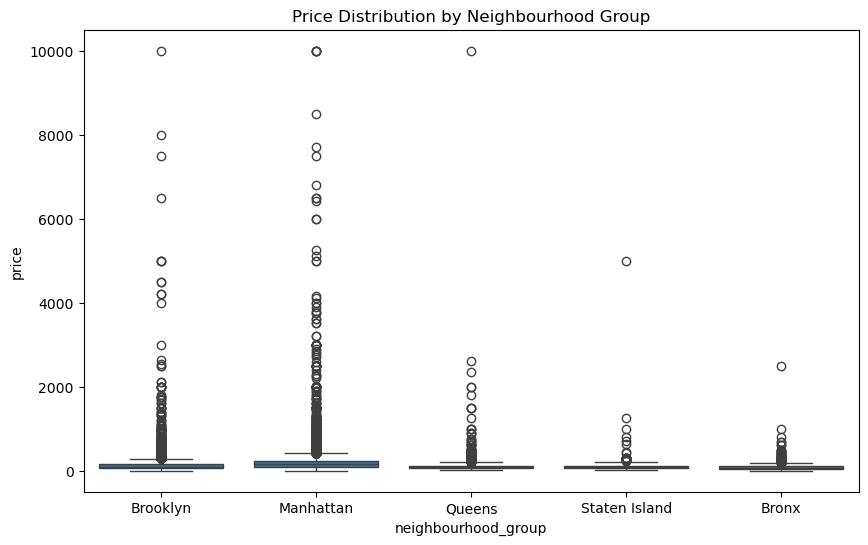

In [33]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="neighbourhood_group",
    y="price",
    data=df
)

plt.title("Price Distribution by Neighbourhood Group")

plt.show()

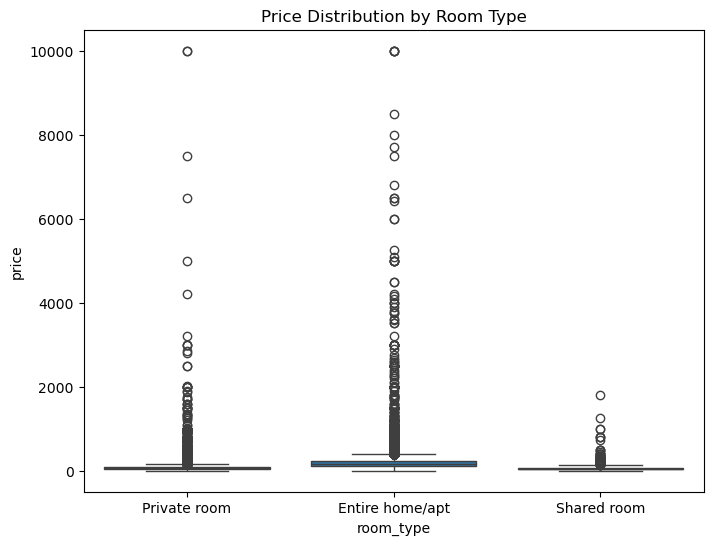

In [34]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="room_type",
    y="price",
    data=df
)

plt.title("Price Distribution by Room Type")

plt.show()

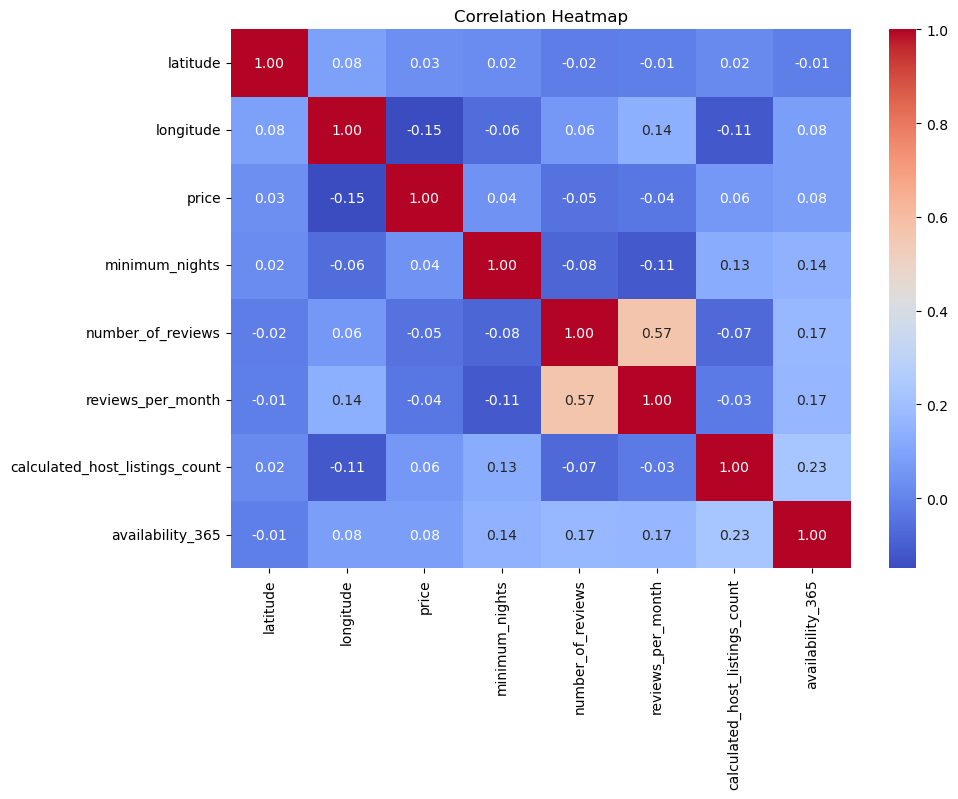

In [35]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.select_dtypes(include=["number"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

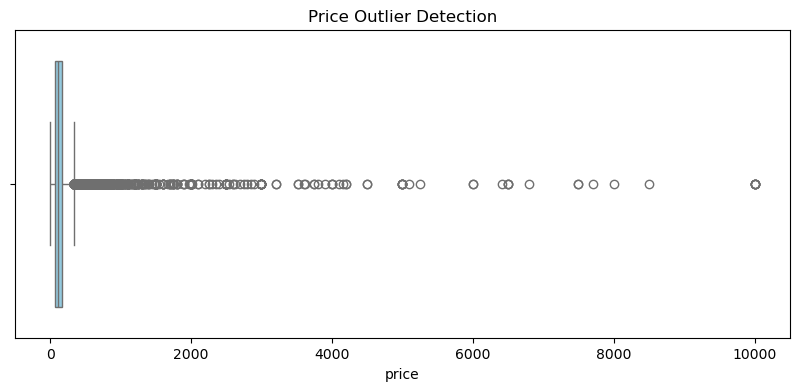

In [36]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df["price"],
    color="skyblue"
)

plt.title("Price Outlier Detection")

plt.show()

In [37]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[
    (df["price"] >= lower) &
    (df["price"] <= upper)
]

print("New Dataset Shape:", df.shape)

New Dataset Shape: (45923, 11)


In [38]:
df.select_dtypes(include="object").columns

Index(['neighbourhood_group', 'neighbourhood', 'room_type'], dtype='str')

In [39]:
# Convert categorical columns into numerical columns
df = pd.get_dummies(
    df,
    columns=[
        "neighbourhood_group",
        "neighbourhood",
        "room_type"
    ],
    drop_first=True
)

df.head()

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,...,neighbourhood_Whitestone,neighbourhood_Williamsbridge,neighbourhood_Williamsburg,neighbourhood_Willowbrook,neighbourhood_Windsor Terrace,neighbourhood_Woodhaven,neighbourhood_Woodlawn,neighbourhood_Woodside,room_type_Private room,room_type_Shared room
0,40.64749,-73.97237,149,1,9,0.21,6,365,True,False,...,False,False,False,False,False,False,False,False,True,False
1,40.75362,-73.98377,225,1,45,0.38,2,355,False,True,...,False,False,False,False,False,False,False,False,False,False
2,40.80902,-73.94190,150,3,0,0.72,1,365,False,True,...,False,False,False,False,False,False,False,False,True,False
3,40.68514,-73.95976,89,1,270,4.64,1,194,True,False,...,False,False,False,False,False,False,False,False,False,False
4,40.79851,-73.94399,80,10,9,0.10,1,0,False,True,...,False,False,False,False,False,False,False,False,False,False


In [40]:
X = df.drop("price", axis=1)

y = df["price"]

In [41]:
print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (45923, 231)
Target Shape   : (45923,)


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [43]:
print(X_train.shape)
print(X_test.shape)

(36738, 231)
(9185, 231)


In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [45]:
models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [49]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    mae = mean_absolute_error(y_test, prediction)

    mse = mean_squared_error(y_test, prediction)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, prediction)

    results.append([
        name,
        mae,
        mse,
        rmse,
        r2
    ])

In [50]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ]
)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

results_df

,Model,MAE,MSE,RMSE,R2 Score
2,Random Forest,31.813292,1991.679102,44.628232,0.572442
3,Gradient Boosting,32.684720,2037.194746,45.135294,0.562671
0,Linear Regression,34.347970,2226.026570,47.180786,0.522134
1,Decision Tree,42.935983,3744.454328,61.191947,0.196169


In [52]:
best_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

best_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [53]:
y_pred = best_model.predict(X_test)

In [54]:
print("Mean Absolute Error :", mean_absolute_error(y_test, y_pred))

Mean Absolute Error : 31.813292142986754


In [55]:
print("Root Mean Squared Error :", np.sqrt(mean_squared_error(y_test, y_pred)))

Root Mean Squared Error : 44.62823212090802


In [56]:
print("R2 Score :", r2_score(y_test, y_pred))

R2 Score : 0.5724416429380831


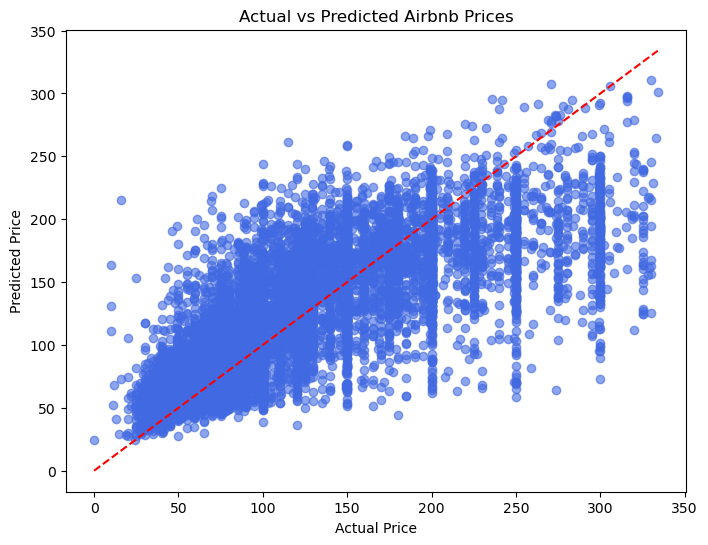

In [57]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6,
    color="royalblue"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Airbnb Prices")

plt.show()

In [58]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": best_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
229,room_type_Private room,0.331360
1,longitude,0.169100
0,latitude,0.139496
6,availability_365,0.068155
4,reviews_per_month,0.060151
230,room_type_Shared room,0.055295
3,number_of_reviews,0.048382
2,minimum_nights,0.045264
5,calculated_host_listings_count,0.029585
8,neighbourhood_group_Manhattan,0.006158


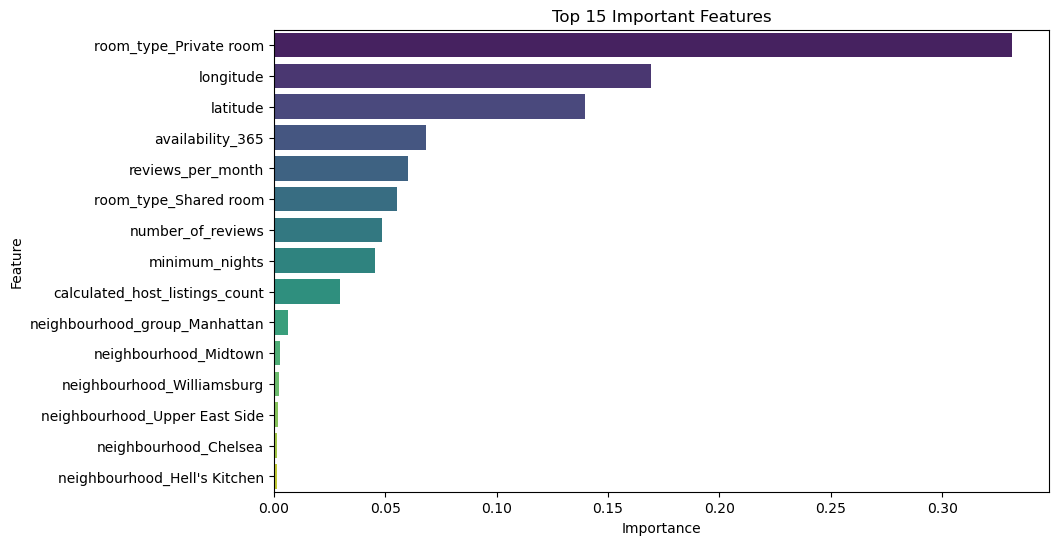

In [59]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(15),
    palette="viridis"
)

plt.title("Top 15 Important Features")

plt.show()

In [60]:
import joblib

joblib.dump(best_model, "airbnb_price_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [61]:
joblib.dump(list(X.columns), "feature_names.pkl")

print("✅ Feature names saved successfully!")

✅ Feature names saved successfully!


In [62]:
model = joblib.load("airbnb_price_model.pkl")

feature_names = joblib.load("feature_names.pkl")

In [63]:
print(feature_names)

['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island', 'neighbourhood_Arden Heights', 'neighbourhood_Arrochar', 'neighbourhood_Arverne', 'neighbourhood_Astoria', 'neighbourhood_Bath Beach', 'neighbourhood_Battery Park City', 'neighbourhood_Bay Ridge', 'neighbourhood_Bay Terrace', 'neighbourhood_Bay Terrace, Staten Island', 'neighbourhood_Baychester', 'neighbourhood_Bayside', 'neighbourhood_Bayswater', 'neighbourhood_Bedford-Stuyvesant', 'neighbourhood_Belle Harbor', 'neighbourhood_Bellerose', 'neighbourhood_Belmont', 'neighbourhood_Bensonhurst', 'neighbourhood_Bergen Beach', 'neighbourhood_Boerum Hill', 'neighbourhood_Borough Park', 'neighbourhood_Breezy Point', 'neighbourhood_Briarwood', 'neighbourhood_Brighton Beach', 'neighbourhood_Bronxdale', 'neighbourhood_Brooklyn He

In [64]:
sample = pd.DataFrame(
    np.zeros((1, len(feature_names))),
    columns=feature_names
)

In [65]:
sample["latitude"] = 40.75
sample["longitude"] = -73.98
sample["minimum_nights"] = 2
sample["number_of_reviews"] = 25
sample["reviews_per_month"] = 1.8
sample["calculated_host_listings_count"] = 3
sample["availability_365"] = 180

# Example categorical values
sample["room_type_Private room"] = 1
sample["neighbourhood_group_Manhattan"] = 1

In [66]:
prediction = model.predict(sample)

print(f"Estimated Airbnb Price: ${prediction[0]:.2f}")

Estimated Airbnb Price: $123.28


In [67]:
print("=" * 50)
print("AIRBNB PRICE PREDICTION MODEL")
print("=" * 50)

print(f"Model : Random Forest Regressor")
print(f"R² Score : {r2_score(y_test, y_pred):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MSE : {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

AIRBNB PRICE PREDICTION MODEL
Model : Random Forest Regressor
R² Score : 0.5724
MAE : 31.8133
MSE : 1991.6791
RMSE : 44.6282


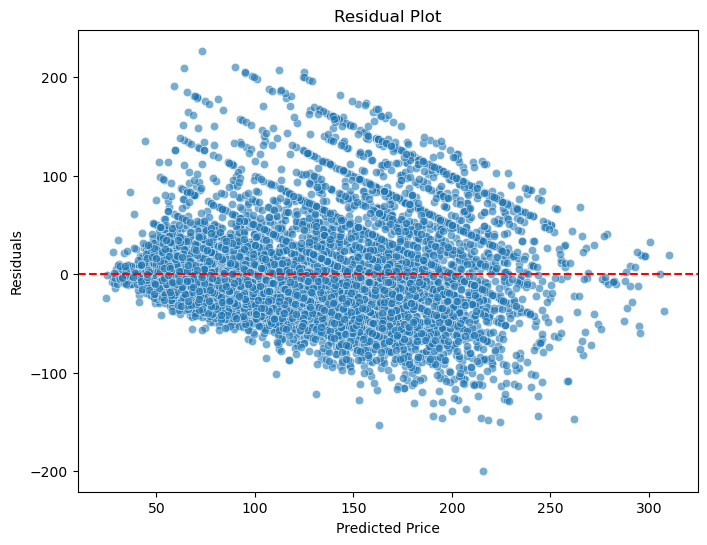

In [68]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_pred,
    y=residuals,
    alpha=0.6
)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [69]:
y = np.log1p(df["price"])

In [70]:
predicted_price = np.expm1(prediction)